In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

In [2]:
from src.features.load_data import load_data

In [3]:
consDF, acctDF, trxnDF, cat_map = load_data()

In [4]:
y = consDF['DQ_TARGET']
X_train, X_test, y_train, y_test = train_test_split(consDF[['prism_consumer_id']], y, test_size=0.20, random_state=42)

# consDF
train_cons = X_train.merge(consDF, on='prism_consumer_id', how='left')
test_cons = X_test.merge(consDF, on='prism_consumer_id', how='left')
# accDF
train_acc = X_train.merge(acctDF, on='prism_consumer_id', how='left')
test_acc = X_test.merge(acctDF, on='prism_consumer_id', how='left')
# trxnDF
train_trxn = X_train.merge(trxnDF, on='prism_consumer_id', how='left')
test_trxn = X_test.merge(trxnDF, on='prism_consumer_id', how='left')


# train_ids = X_train['prism_consumer_id']
# train_dq = X_train['DQ_TARGET']

# test_ids = X_test['prism_consumer_id']
# test_dq = X_test['DQ_TARGET']

# X_train = X_train.drop(columns=['prism_consumer_id'])
# X_train = X_train.drop(columns=['DQ_TARGET'])
# X_test = X_test.drop(columns=['prism_consumer_id'])
# X_test = X_test.drop(columns=['DQ_TARGET'])

In [5]:
train_trxn

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
0,11182,3147774,0.0,50.00,CREDIT,2021-06-08
1,11182,3147775,0.0,50.00,CREDIT,2021-06-15
2,11182,3147776,0.0,200.00,CREDIT,2021-08-10
3,11182,3147777,0.0,85.99,CREDIT,2021-08-23
4,11182,3147778,7.0,0.01,CREDIT,2021-09-15
...,...,...,...,...,...,...
3942174,8270,1945100,16.0,63.40,DEBIT,2023-01-05
3942175,8270,1945101,18.0,17.50,DEBIT,2023-01-05
3942176,8270,1945102,20.0,1.99,DEBIT,2023-01-06
3942177,8270,1945103,4.0,4.99,DEBIT,2023-01-09


In [6]:
test_trxn

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
0,1935,559350,4.0,0.38,CREDIT,2021-10-08
1,1935,559351,0.0,8000.00,CREDIT,2021-10-24
2,1935,559352,4.0,0.46,CREDIT,2021-11-12
3,1935,559353,4.0,0.36,CREDIT,2021-12-10
4,1935,559354,4.0,0.36,CREDIT,2022-01-14
...,...,...,...,...,...,...
965466,5414,2183364,14.0,40.77,DEBIT,2023-10-06
965467,5414,2183365,0.0,20.00,DEBIT,2023-10-06
965468,5414,2183366,12.0,64.07,DEBIT,2023-10-06
965469,5414,2183367,12.0,88.03,DEBIT,2023-10-06


In [7]:
# income_cats = [2,3,5,7,8,9,49]

In [8]:
# def compute_income_from_eval_windows(
#     txn_df: pd.DataFrame,
#     cons_df: pd.DataFrame,
#     income_cats = [2,3,5,7,8,9,49],
#     windows=[1,3,6,12],  # months
#     consumer_col: str = "prism_consumer_id",
#     txn_date_col: str = "posted_date",
#     eval_date_col: str = "evaluation_date",
#     amt_col: str = "amount",
#     direction_col: str = "credit_or_debit",
#     category_col: str = "category",
# ) -> pd.DataFrame:
#     """
#     For each consumer, compute income over multiple month windows
#     prior to (and including) evaluation_date.

#     Returns:
#         DataFrame with one row per consumer and columns:
#         income_last_{W}m for each W in windows
#     """

#     tx = txn_df.copy()
#     cons = cons_df[[consumer_col, eval_date_col]].copy()

#     tx[txn_date_col] = pd.to_datetime(tx[txn_date_col])
#     cons[eval_date_col] = pd.to_datetime(cons[eval_date_col])

#     # Keep only income transactions
#     tx = tx[
#         (tx[direction_col] == "CREDIT") &
#         (tx[category_col].isin(income_cats))
#     ].copy()

#     # Attach evaluation_date
#     tx = tx.merge(cons, on=consumer_col, how="inner")

#     # Start with full consumer base
#     output = cons[[consumer_col]].drop_duplicates().copy()

#     for W in windows:

#         start = tx[eval_date_col] - pd.DateOffset(months=W)

#         tx_window = tx[
#             (tx[txn_date_col] >= start) &
#             (tx[txn_date_col] <= tx[eval_date_col])
#         ]

#         agg = (
#             tx_window
#             .groupby(consumer_col, as_index=False)[amt_col]
#             .sum()
#             .rename(columns={amt_col: f"income_last_{W}m"})
#         )

#         output = output.merge(agg, on=consumer_col, how="left")

#     # Fill consumers with no income as 0
#     for W in windows:
#         col = f"income_last_{W}m"
#         if col in output.columns:
#             output[col] = output[col].fillna(0.0)

#     return output


# def fit_trans_income_binner_and_ohe(income_df, q=5, prefix="income_last_"):
#     """
#     TRAINING:
#       - For each income window column:
#           try qcut -> store bin_edges + scheme
#           fallback to cut -> store bin_edges + scheme
#       - Create *_bin columns
#       - Fit OneHotEncoder on *_bin
#     Returns:
#       out_df, artifacts
#         artifacts = {
#           "binning": {col: {"edges": array, "method": "qcut"/"cut", "labels": [...]}}
#           "bin_cols": [...],
#           "ohe": fitted OneHotEncoder
#         }
#     """
#     df = income_df.copy()
#     income_cols = [c for c in df.columns if c.startswith(prefix)]

#     binning = {}
#     bin_cols = []

#     for col in income_cols:
#         bin_col = f"{col}_bin"
#         bin_cols.append(bin_col)

#         # If you want to treat NaNs explicitly, keep them as NaN here.
#         # OHE can handle unknowns, but NaN will be a category unless you impute or set dtype.
#         x = df[col]

#         try:
#             labels = [f"Q{i+1}" for i in range(q)]
#             binned, edges = pd.qcut(
#                 x, q=q, labels=labels, duplicates="drop", retbins=True
#             )
#             method = "qcut"
#             # When duplicates="drop", actual number of bins may be < q:
#             actual_bins = len(edges) - 1
#             labels = labels[:actual_bins]
#             # Re-run with the truncated labels to keep things consistent
#             binned = pd.cut(x, bins=edges, labels=labels, include_lowest=True)

#         except ValueError:
#             labels = [f"B{i+1}" for i in range(q)]
#             binned, edges = pd.cut(
#                 x, bins=q, labels=labels, retbins=True, include_lowest=True
#             )
#             method = "cut"

#         df[bin_col] = binned.astype("object")  # keep as categorical-like
#         binning[col] = {"edges": np.asarray(edges), "method": method, "labels": list(labels)}

#     ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
#     transformed = ohe.fit_transform(df[bin_cols])

#     one_hot_df = pd.DataFrame(
#         transformed,
#         columns=ohe.get_feature_names_out(bin_cols),
#         index=df.index
#     )

#     out = pd.concat([df, one_hot_df], axis=1)

#     artifacts = {"binning": binning, "bin_cols": bin_cols, "ohe": ohe}
#     return out, artifacts


# def transform_income_with_artifacts(income_df, artifacts, prefix="income_last_"):
#     """
#     INFERENCE:
#       - Use stored bin edges per column to create *_bin
#       - Use stored fitted OHE to transform
#       - Returns out_df with same one-hot columns as training
#     """
#     df = income_df.copy()
#     binning = artifacts["binning"]
#     bin_cols = artifacts["bin_cols"]
#     ohe = artifacts["ohe"]

#     # Build bins deterministically using stored edges
#     for col, meta in binning.items():
#         edges = meta["edges"].copy()
#         labels = meta["labels"]

#         # Optional: make bins cover any future out-of-range values
#         # (prevents NaNs when new data exceeds training min/max)
#         edges[0] = -np.inf
#         edges[-1] = np.inf

#         bin_col = f"{col}_bin"
#         df[bin_col] = pd.cut(
#             df[col],
#             bins=edges,
#             labels=labels,
#             include_lowest=True
#         ).astype("object")

#     # Ensure all expected bin cols exist (in case some income columns are missing)
#     for bc in bin_cols:
#         if bc not in df.columns:
#             df[bc] = np.nan

#     transformed = ohe.transform(df[bin_cols])
#     one_hot_df = pd.DataFrame(
#         transformed,
#         columns=ohe.get_feature_names_out(bin_cols),
#         index=df.index
#     )
#     out = pd.concat([df, one_hot_df], axis=1)
#     return out

In [9]:
from src.features.ada.last_m_income_and_bins import compute_income_from_eval_windows, fit_trans_income_binner_and_ohe, transform_income_with_artifacts

In [10]:
train_income_df = compute_income_from_eval_windows(train_trxn, train_cons)
test_income_df = compute_income_from_eval_windows(test_trxn, test_cons)
# binned_df, bin_edges = fit_income_binner_and_ohe(last_m_income, q=5, prefix="income_last_")
# binned_df = transform_income_with_artifacts(last_m_income, bin_edges, prefix="income_last_")

X_train, bin_edges = fit_trans_income_binner_and_ohe(train_income_df, q=5)

X_test = transform_income_with_artifacts(test_income_df, bin_edges)
# last_m_income[['income_last_1m', 'income_last_3m',	'income_last_6m', 'income_last_12m']] = np.log1p(last_m_income[['income_last_1m', 'income_last_3m',	'income_last_6m', 'income_last_12m']])

In [11]:
X_train

,prism_consumer_id,income_last_1m,income_last_3m,income_last_6m,income_last_12m,income_last_1m_bin,income_last_3m_bin,income_last_6m_bin,income_last_12m_bin,income_last_1m_bin_Q2,...,income_last_3m_bin_Q4,income_last_3m_bin_Q5,income_last_6m_bin_Q2,income_last_6m_bin_Q3,income_last_6m_bin_Q4,income_last_6m_bin_Q5,income_last_12m_bin_Q2,income_last_12m_bin_Q3,income_last_12m_bin_Q4,income_last_12m_bin_Q5
0,11182,1442.54,5111.82,8506.60,9815.94,Q2,Q2,Q3,Q3,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,13091,5525.51,21685.20,42972.11,57504.62,Q4,Q5,Q5,Q5,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,7428,0.00,5150.00,5150.00,5150.00,Q1,Q2,Q2,Q2,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,288,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2626,6477.52,14145.51,23384.91,23384.91,Q5,Q4,Q4,Q4,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,13964,1788.83,8378.97,15770.30,18440.48,Q2,Q3,Q4,Q4,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9596,6191,7851.33,23214.42,23214.42,23214.42,Q5,Q5,Q4,Q4,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9597,6390,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9598,860,3236.64,5098.18,5398.18,5398.18,Q3,Q2,Q2,Q2,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [12]:
X_test

,prism_consumer_id,income_last_1m,income_last_3m,income_last_6m,income_last_12m,income_last_1m_bin,income_last_3m_bin,income_last_6m_bin,income_last_12m_bin,income_last_1m_bin_Q2,...,income_last_3m_bin_Q4,income_last_3m_bin_Q5,income_last_6m_bin_Q2,income_last_6m_bin_Q3,income_last_6m_bin_Q4,income_last_6m_bin_Q5,income_last_12m_bin_Q2,income_last_12m_bin_Q3,income_last_12m_bin_Q4,income_last_12m_bin_Q5
0,1935,0.00,0.00,3582.88,3582.88,Q1,Q1,Q2,Q2,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,7494,4777.29,15614.81,15614.81,15614.81,Q4,Q4,Q4,Q3,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1720,2050.33,3160.64,3160.64,3160.64,Q3,Q2,Q2,Q2,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,11120,3100.52,3100.52,7561.04,7561.55,Q3,Q2,Q2,Q2,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,360,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,1195,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2396,13877,756.90,3310.70,5824.50,7253.70,Q2,Q2,Q2,Q2,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2397,6421,6265.09,16871.61,16871.61,16871.61,Q5,Q5,Q4,Q4,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2398,3855,1916.26,4108.16,5158.07,5158.07,Q3,Q2,Q2,Q2,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [13]:
bin_edges

{'binning': {'income_last_1m': {'edges': array([0.0000000e+00, 4.0000000e+01, 1.9104400e+03, 3.3641840e+03,
          5.6594460e+03, 3.8277983e+05]),
   'method': 'qcut',
   'labels': ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']},
  'income_last_3m': {'edges': array([0.00000000e+00, 8.99120000e+02, 5.74391600e+03, 9.99176800e+03,
          1.63586100e+04, 1.19966576e+06]),
   'method': 'qcut',
   'labels': ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']},
  'income_last_6m': {'edges': array([      0.   ,    1514.458,    8250.73 ,   14551.434,   25115.012,
          1199665.76 ]),
   'method': 'qcut',
   'labels': ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']},
  'income_last_12m': {'edges': array([      0.   ,    1699.77 ,    8839.188,   15893.476,   29194.32 ,
          1285438.26 ]),
   'method': 'qcut',
   'labels': ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']}},
 'bin_cols': ['income_last_1m_bin',
  'income_last_3m_bin',
  'income_last_6m_bin',
  'income_last_12m_bin'],
 'ohe': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_out

In [14]:
# def outlying_spending_ratio(
#     txn_df,
#     consumer_col="prism_consumer_id",
#     amt_col="amount",
#     direction_col="credit_or_debit",
#     debit_value="DEBIT",
#     iqr_k=1.5
# ):
#     """
#     Computes:
#         outlying_debit_ratio =
#         (# debit txns above Q3 + k*IQR) / (# all debit txns)
#     """

#     df = txn_df.copy()

#     # Keep only debit transactions
#     df = df[df[direction_col] == debit_value].copy()
#     df[amt_col] = pd.to_numeric(df[amt_col], errors="coerce")
#     df = df[df[amt_col].notna() & (df[amt_col] > 0)]

#     if df.empty:
#         return pd.DataFrame(columns=[
#             consumer_col,
#             "debit_txn_count",
#             "outlying_debit_count",
#             "outlying_debit_ratio"
#         ])

#     g = df.groupby(consumer_col)

#     # Compute IQR stats per consumer
#     q1 = g[amt_col].quantile(0.25)
#     q3 = g[amt_col].quantile(0.75)
#     iqr = q3 - q1
#     upper_bound = q3 + iqr_k * iqr

#     thresholds = upper_bound.rename("upper_bound").reset_index()

#     # Merge thresholds back
#     df = df.merge(thresholds, on=consumer_col, how="left")

#     # Flag outliers
#     df["is_outlier"] = df[amt_col] > df["upper_bound"]

#     # Aggregate counts
#     result = (
#         df.groupby(consumer_col)
#           .agg(
#               debit_txn_count=(amt_col, "size"),
#               outlying_debit_count=("is_outlier", "sum")
#           )
#           .reset_index()
#     )

#     # Ratio
#     result["outlying_debit_ratio"] = (
#         result["outlying_debit_count"] / result["debit_txn_count"]
#     )

#     return result

In [15]:
from src.features.ada.outlying_spending_ratio import outlying_spending_ratio
outlier_feats = outlying_spending_ratio(trxnDF, iqr_k=1.5)

X_train = X_train.merge(outlier_feats, on='prism_consumer_id', how='left')
X_test = X_test.merge(outlier_feats, on='prism_consumer_id', how='left')

X_test

,prism_consumer_id,income_last_1m,income_last_3m,income_last_6m,income_last_12m,income_last_1m_bin,income_last_3m_bin,income_last_6m_bin,income_last_12m_bin,income_last_1m_bin_Q2,...,income_last_3m_bin_Q5,income_last_6m_bin_Q2,income_last_6m_bin_Q3,income_last_6m_bin_Q4,income_last_6m_bin_Q5,income_last_12m_bin_Q2,income_last_12m_bin_Q3,income_last_12m_bin_Q4,income_last_12m_bin_Q5,outlying_spending_ratio
0,1935,0.00,0.00,3582.88,3582.88,Q1,Q1,Q2,Q2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.180556
1,7494,4777.29,15614.81,15614.81,15614.81,Q4,Q4,Q4,Q3,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.074656
2,1720,2050.33,3160.64,3160.64,3160.64,Q3,Q2,Q2,Q2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.111437
3,11120,3100.52,3100.52,7561.04,7561.55,Q3,Q2,Q2,Q2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.101942
4,360,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,1195,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2396,13877,756.90,3310.70,5824.50,7253.70,Q2,Q2,Q2,Q2,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.153846
2397,6421,6265.09,16871.61,16871.61,16871.61,Q5,Q5,Q4,Q4,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.044444
2398,3855,1916.26,4108.16,5158.07,5158.07,Q3,Q2,Q2,Q2,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.129187


In [16]:
# merged = consDF.merge(last_m_income, on='prism_consumer_id', how='left')
# merged = merged.merge(outlier_feats[['prism_consumer_id', 'outlying_debit_ratio']], on='prism_consumer_id', how='left')
# merged
# merged = consDF.merge(last_m_income, on='prism_consumer_id', how='left')


In [17]:
all_feats = pd.read_parquet('all_feats_do_not_push.parquet')
X_train = X_train.merge(all_feats, on = 'prism_consumer_id', how = 'left')
X_test = X_test.merge(all_feats, on = 'prism_consumer_id', how = 'left')

In [18]:
X_train

,prism_consumer_id,income_last_1m,income_last_3m,income_last_6m,income_last_12m,income_last_1m_bin,income_last_3m_bin,income_last_6m_bin,income_last_12m_bin,income_last_1m_bin_Q2,...,avg_cat47_spend_6m,med_cat47_spend_6m,sd_cat47_spend_6m,min_cat47_spend_6m,max_cat47_spend_6m,avg_cat47_to_income_ratio_6m,med_cat47_to_income_ratio_6m,sd_cat47_to_income_ratio_6m,min_cat47_to_income_ratio_6m,max_cat47_to_income_ratio_6m
0,11182,1442.54,5111.82,8506.60,9815.94,Q2,Q2,Q3,Q3,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,13091,5525.51,21685.20,42972.11,57504.62,Q4,Q5,Q5,Q5,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,7428,0.00,5150.00,5150.00,5150.00,Q1,Q2,Q2,Q2,0.0,...,4.483801,3.255112,4.377882,1.486178,8.901168,0.000194,0.000189,0.000109,0.000121,0.000273
3,288,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2626,6477.52,14145.51,23384.91,23384.91,Q5,Q4,Q4,Q4,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,13964,1788.83,8378.97,15770.30,18440.48,Q2,Q3,Q4,Q4,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9596,6191,7851.33,23214.42,23214.42,23214.42,Q5,Q5,Q4,Q4,0.0,...,4.483801,3.255112,4.377882,1.486178,8.901168,0.000194,0.000189,0.000109,0.000121,0.000273
9597,6390,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9598,860,3236.64,5098.18,5398.18,5398.18,Q3,Q2,Q2,Q2,0.0,...,0.000000,0.000000,4.377882,0.000000,0.000000,0.000000,0.000000,0.000109,0.000000,0.000000


In [19]:
X_test

,prism_consumer_id,income_last_1m,income_last_3m,income_last_6m,income_last_12m,income_last_1m_bin,income_last_3m_bin,income_last_6m_bin,income_last_12m_bin,income_last_1m_bin_Q2,...,avg_cat47_spend_6m,med_cat47_spend_6m,sd_cat47_spend_6m,min_cat47_spend_6m,max_cat47_spend_6m,avg_cat47_to_income_ratio_6m,med_cat47_to_income_ratio_6m,sd_cat47_to_income_ratio_6m,min_cat47_to_income_ratio_6m,max_cat47_to_income_ratio_6m
0,1935,0.00,0.00,3582.88,3582.88,Q1,Q1,Q2,Q2,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,7494,4777.29,15614.81,15614.81,15614.81,Q4,Q4,Q4,Q3,0.0,...,4.483801,3.255112,4.377882,1.486178,8.901168,0.000194,0.000189,0.000109,0.000121,0.000273
2,1720,2050.33,3160.64,3160.64,3160.64,Q3,Q2,Q2,Q2,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,11120,3100.52,3100.52,7561.04,7561.55,Q3,Q2,Q2,Q2,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,360,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,1195,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,...,0.000000,0.000000,4.377882,0.000000,0.000000,0.000194,0.000189,0.000109,0.000121,0.000273
2396,13877,756.90,3310.70,5824.50,7253.70,Q2,Q2,Q2,Q2,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2397,6421,6265.09,16871.61,16871.61,16871.61,Q5,Q5,Q4,Q4,0.0,...,4.483801,3.255112,4.377882,1.486178,8.901168,0.000194,0.000189,0.000109,0.000121,0.000273
2398,3855,1916.26,4108.16,5158.07,5158.07,Q3,Q2,Q2,Q2,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [20]:
# # consumer_ids = X['prism_consumer_id']
# y = X['DQ_TARGET']
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


train_ids = X_train['prism_consumer_id']
train_dq = X_train[['prism_consumer_id']].merge(consDF, on='prism_consumer_id', how='left')['DQ_TARGET']
train_eval = X_train[['prism_consumer_id']].merge(consDF, on='prism_consumer_id', how='left')['evaluation_date']

test_ids = X_test['prism_consumer_id']
test_dq = X_test[['prism_consumer_id']].merge(consDF, on='prism_consumer_id', how='left')['DQ_TARGET']
test_eval = X_test[['prism_consumer_id']].merge(consDF, on='prism_consumer_id', how='left')['evaluation_date']


X_train = X_train.drop(columns=['prism_consumer_id'])
X_test = X_test.drop(columns=['prism_consumer_id'])

In [21]:
all_feats.shape

(12000, 1167)

In [22]:
X_train

,income_last_1m,income_last_3m,income_last_6m,income_last_12m,income_last_1m_bin,income_last_3m_bin,income_last_6m_bin,income_last_12m_bin,income_last_1m_bin_Q2,income_last_1m_bin_Q3,...,avg_cat47_spend_6m,med_cat47_spend_6m,sd_cat47_spend_6m,min_cat47_spend_6m,max_cat47_spend_6m,avg_cat47_to_income_ratio_6m,med_cat47_to_income_ratio_6m,sd_cat47_to_income_ratio_6m,min_cat47_to_income_ratio_6m,max_cat47_to_income_ratio_6m
0,1442.54,5111.82,8506.60,9815.94,Q2,Q2,Q3,Q3,1.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,5525.51,21685.20,42972.11,57504.62,Q4,Q5,Q5,Q5,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.00,5150.00,5150.00,5150.00,Q1,Q2,Q2,Q2,0.0,0.0,...,4.483801,3.255112,4.377882,1.486178,8.901168,0.000194,0.000189,0.000109,0.000121,0.000273
3,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6477.52,14145.51,23384.91,23384.91,Q5,Q4,Q4,Q4,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,1788.83,8378.97,15770.30,18440.48,Q2,Q3,Q4,Q4,1.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9596,7851.33,23214.42,23214.42,23214.42,Q5,Q5,Q4,Q4,0.0,0.0,...,4.483801,3.255112,4.377882,1.486178,8.901168,0.000194,0.000189,0.000109,0.000121,0.000273
9597,0.00,0.00,0.00,0.00,Q1,Q1,Q1,Q1,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9598,3236.64,5098.18,5398.18,5398.18,Q3,Q2,Q2,Q2,0.0,1.0,...,0.000000,0.000000,4.377882,0.000000,0.000000,0.000000,0.000000,0.000109,0.000000,0.000000


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
import time
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
pca = PCA(n_components = 100) #max = number of feats in X_train
from sklearn.preprocessing import StandardScaler, OneHotEncoder
scaler = StandardScaler()
from sklearn.preprocessing import Normalizer
norm = Normalizer()

logreg = LogisticRegression(
    solver="saga",
    penalty="l1",
    C=0.1,
    max_iter=5000,
    tol=1e-3,
    random_state=0
)

from sklearn.feature_selection import VarianceThreshold
# pipe = Pipeline([("vt", VarianceThreshold(1e-6)),
#                  ('scaler', scaler),  
#                  ('pca', pca), 
#                  ('normalize', norm),
#                   ('logreg', logreg)
#          ])

cat_cols = ['income_last_1m_bin', 'income_last_3m_bin',	'income_last_6m_bin', 'income_last_12m_bin']

categorical = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

from sklearn.compose import ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical, cat_cols)
    ],
    remainder="passthrough"
)

pipe = Pipeline([
    ("prep", preprocess),
    ('inpute', SimpleImputer(strategy="median")),
    ("vt", VarianceThreshold(1e-6)),
    ('scaler', scaler), 
    # ('pca', pca), 
    ('normalize', norm),
    ('logreg', logreg),
    # ("model", LogisticRegression(max_iter=2000))
])

param_grid = [
    # # lbfgs + l2 only
    # {
    #     "pca__n_components": [350, 400, 500, 600],
    #     "logreg__solver": ["lbfgs"],
    #     "logreg__penalty": ["l2"],
    #     "logreg__C": [0.01, 0.1, 1.0],
    #     "logreg__max_iter": [1500, 2000, 2500],
    #     "logreg__tol": [1e-4, 1e-3],
    # },
    # saga + l1/l2
    {
        # "pca__n_components": [300, 350, 400], #prev:500, 350
        "logreg__solver": ["saga"],
        "logreg__penalty": ["l1", "l2"],
        "logreg__C": [0.01, 0.1, 1.0],
        "logreg__max_iter": [2000], #prev: 2000, 1700, 2000
        "logreg__tol": [1e-4, 1e-3],
    },
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose = 1,
    error_score="raise"
)

t0 = time.perf_counter()
grid.fit(X_train, y_train)
grid_fit_s = time.perf_counter() - t0

logreg_best = grid.best_estimator_

print("best estimator:", grid.best_estimator_)
print("best params:", grid.best_params_)

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

print(f"\n[Latency] GridSearchCV.fit total: {grid_fit_s:.2f} s "
      f"({grid_fit_s/60:.2f} min)")

# --- Best estimator refit time (optional but useful) ---
# Note: GridSearchCV already refits best_estimator_ by default, but we time it explicitly.
t0 = time.perf_counter()
logreg_best.fit(X_train, y_train)
logreg_best_fit_s = time.perf_counter() - t0

# --- Train scoring latency ---
t0 = time.perf_counter()
preds_train = logreg_best.predict_proba(X_train)[:, 1]
pred_train_s = time.perf_counter() - t0

t0 = time.perf_counter()
train_auc = roc_auc_score(y_train, preds_train)
train_auc_s = time.perf_counter() - t0

# --- Test scoring latency ---
t0 = time.perf_counter()
preds_test = logreg_best.predict_proba(X_test)[:, 1]
lr_pred_test_s = time.perf_counter() - t0

t0 = time.perf_counter()
test_auc = roc_auc_score(y_test, preds_test)
test_auc_s = time.perf_counter() - t0

print("\nPerformance")
print(f"best CV auc: {grid.best_score_}")
print(f"train auc-roc: {train_auc:.6f}")
print(f"test  auc-roc: {test_auc:.6f}")

print("\n[Latency] Best-estimator timings")
print(f"logreg_best.fit(X_train,y_train):      {logreg_best_fit_s:.4f} s")
print(f"predict_proba(X_train):         {pred_train_s:.4f} s")
print(f"roc_auc_score(train):           {train_auc_s:.6f} s")
print(f"predict_proba(X_test):          {lr_pred_test_s:.4f} s")
print(f"roc_auc_score(test):            {test_auc_s:.6f} s")

# Optional: per-row latency (useful for “serving” style reporting)
ntr = len(y_train)
nte = len(y_test)
print("\n[Latency] Per-row (approx)")
print(f"train predict_proba per row: {pred_train_s/ntr*1e3:.6f} ms")
print(f"test  predict_proba per row: {lr_pred_test_s/nte*1e3:.6f} ms")

# best params: {'logreg__C': 1.0, 'logreg__max_iter': 2000, 'logreg__penalty': 'l2', 'logreg__solver': 'saga', 'logreg__tol': 0.0001, 'pca__n_components': 350}
# best CV auc: 0.715231153074429
# train auc-roc:  0.7816872975962226
# test auc-roc:  0.7672276059787072

# best params: {'logreg__C': 1.0, 'logreg__max_iter': 2000, 'logreg__penalty': 'l2', 'logreg__solver': 'saga', 'logreg__tol': 0.001, 'pca__n_components': 350}
# best CV auc: 0.7151557716708414
# train auc-roc:  0.7815749892667357
# test auc-roc:  0.7674142539308059

Fitting 3 folds for each of 12 candidates, totalling 36 fits
best estimator: Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['income_last_1m_bin',
                                                   'income_last_3m_bin',
                                                   'income_last_6m_bin',
                                                   'income_last_12m_bin'])])),
                ('inpute', SimpleImputer(strategy='median')),
                ('vt', VarianceThreshold(threshold=1e-06)),
                ('scaler', StandardScaler()), ('normalize', Normalizer()),
                ('logreg',
                 LogisticRegression(max_iter=2000, penalty='l1', random_

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
import time
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV


rf = RandomForestClassifier(random_state=0)
# imputer = SimpleImputer(strategy="mean", add_indicator=True)
# skb = SelectKBest(mutual_info_classif, k=300)


cat_cols = ['income_last_1m_bin', 'income_last_3m_bin',	'income_last_6m_bin', 'income_last_12m_bin']

categorical = Pipeline([
    ("onehot", OneHotEncoder(drop='first')),
])

from sklearn.compose import ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical, cat_cols)
    ],
    remainder="passthrough"
)

pipe = Pipeline([
    ("prep", preprocess),
    ('rf', rf)
])


param_grid = {
    "rf__n_estimators": [400],#[350, 400, 450],
    "rf__max_features": [0.1], #["sqrt", 0.1],
    "rf__max_depth": [20], #[15, 20],
    "rf__min_samples_split": [10], #[10, 20],
    "rf__min_samples_leaf": [20], #[20, 50],
    "rf__class_weight": ["balanced"],
}


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

t0 = time.perf_counter()
grid.fit(X_train, y_train)
grid_fit_s = time.perf_counter() - t0

rf_best = grid.best_estimator_

print("best estimator:", grid.best_estimator_)
print("best params:", grid.best_params_)

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

print(f"\n[Latency] GridSearchCV.fit total: {grid_fit_s:.2f} s "
      f"({grid_fit_s/60:.2f} min)")

# --- Best estimator refit time (optional but useful) ---
# Note: GridSearchCV already refits best_estimator_ by default, but we time it explicitly.
t0 = time.perf_counter()
rf_best.fit(X_train, y_train)
rf_best_fit_s = time.perf_counter() - t0

# --- Train scoring latency ---
t0 = time.perf_counter()
preds_train = rf_best.predict_proba(X_train)[:, 1]
pred_train_s = time.perf_counter() - t0

t0 = time.perf_counter()
train_auc = roc_auc_score(y_train, preds_train)
train_auc_s = time.perf_counter() - t0

# --- Test scoring latency ---
t0 = time.perf_counter()
preds_test = rf_best.predict_proba(X_test)[:, 1]
rf_pred_test_s = time.perf_counter() - t0

t0 = time.perf_counter()
test_auc = roc_auc_score(y_test, preds_test)
test_auc_s = time.perf_counter() - t0

print("\nPerformance")
print(f"best CV auc: {grid.best_score_}")
print(f"train auc-roc: {train_auc:.6f}")
print(f"test  auc-roc: {test_auc:.6f}")

print("\n[Latency] Best-estimator timings")
print(f"best.fit(X_train,y_train):      {rf_best_fit_s:.4f} s")
print(f"predict_proba(X_train):         {pred_train_s:.4f} s")
print(f"roc_auc_score(train):           {train_auc_s:.6f} s")
print(f"predict_proba(X_test):          {rf_pred_test_s:.4f} s")
print(f"roc_auc_score(test):            {test_auc_s:.6f} s")

# Optional: per-row latency (useful for “serving” style reporting)
ntr = len(y_train)
nte = len(y_test)
print("\n[Latency] Per-row (approx)")
print(f"train predict_proba per row: {pred_train_s/ntr*1e3:.6f} ms")
print(f"test  predict_proba per row: {rf_pred_test_s/nte*1e3:.6f} ms")

# best params: {'rf__class_weight': 'balanced', 'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 500}
# best CV auc: 0.7226789743202131
# train auc-roc:  0.8906017357086465
# test auc-roc:  0.7368301204999179

# best params: {'rf__class_weight': 'balanced', 'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 600}
# best CV auc: 0.730654200845845
# train auc-roc:  0.9997834392127612
# test auc-roc:  0.7587873855848054

Fitting 3 folds for each of 1 candidates, totalling 3 fits
best estimator: Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['income_last_1m_bin',
                                                   'income_last_3m_bin',
                                                   'income_last_6m_bin',
                                                   'income_last_12m_bin'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        max_features=0.1, min_samples_leaf=20,
                                        min_samples_split=10, n_estimators=400,
                                        random_s

In [25]:
best_rf = rf_best.named_steps["rf"] 

importances = best_rf.feature_importances_ 
feature_names = rf_best.named_steps["prep"].get_feature_names_out() 

fi_df = pd.DataFrame({ "feature": feature_names, 
                      "importance": importances 
                     }).sort_values("importance", ascending=False).reset_index(drop=True)
fi_df.index.name = 'Feature Importance Ranking'

new_feats = ['remainder__income_last_1m', 'remainder__income_last_3m', 'remainder__income_last_6m', 'remainder__income_last_12m', 'remainder__outlying_spending_ratio', 
             'cat__income_last_1m_bin_Q2', 'cat__income_last_1m_bin_Q3', 'cat__income_last_1m_bin_Q4', 'cat__income_last_1m_bin_Q5', 
             'cat__income_last_3m_bin_Q2', 'cat__income_last_3m_bin_Q3', 'cat__income_last_3m_bin_Q4', 'cat__income_last_3m_bin_Q5', 
             'cat__income_last_6m_bin_Q2', 'cat__income_last_6m_bin_Q3', 'cat__income_last_6m_bin_Q4', 'cat__income_last_6m_bin_Q5', 
             'cat__income_last_12m_bin_Q2', 'cat__income_last_12m_bin_Q3', 'cat__income_last_12m_bin_Q4', 'cat__income_last_12m_bin_Q5' 
            ] 

fi_df[fi_df['feature'].isin(new_feats)] 

,feature,importance
Feature Importance Ranking,,
48,remainder__outlying_spending_ratio,0.002303
90,remainder__income_last_1m,0.001790
184,remainder__income_last_12m,0.001265
219,remainder__income_last_6m,0.001155
294,remainder__income_last_3m,0.001000
805,cat__income_last_6m_bin_Q2,0.000211
872,cat__income_last_3m_bin_Q4,0.000167
874,cat__income_last_1m_bin_Q4,0.000165
1002,cat__income_last_6m_bin_Q4,0.000101


In [26]:
fi_df

,feature,importance
Feature Importance Ranking,,
0,remainder__liquid_balance,0.026323
1,remainder__total_balance,0.023429
2,remainder__months_observed,0.018996
3,remainder__mean_balance_30d,0.016880
4,remainder__mean_balance_365d,0.016659
...,...,...
1198,remainder__med_cat33_to_income_ratio_3m,0.000000
1199,remainder__max_cat11_to_income_ratio_6m,0.000000
1200,remainder__min_cat25_to_income_ratio_1m,0.000000


## auc-roc graphs

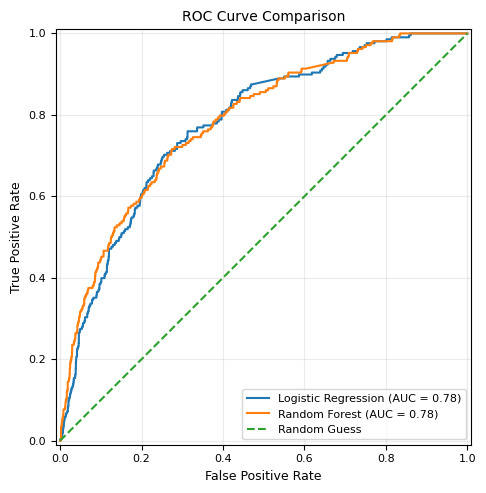

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Make fonts smaller globally (optional but clean)
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})


fig, ax = plt.subplots(figsize=(15, 5))

RocCurveDisplay.from_estimator(logreg_best, X_test, y_test, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_estimator(rf_best, X_test, y_test, name="Random Forest", ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", label='Random Guess')
ax.set_title("ROC Curve Comparison")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


In [28]:
# latency graph
latency = pd.DataFrame({
    'model': ['logreg', 'randomforest'],
    'AUC-ROC': [0.7, 0.8],
    'latency': [f'{lr_pred_test_s:.3f} ms', f'{rf_pred_test_s:.3f} ms']
})
latency = latency.set_index('model')
latency

,AUC-ROC,latency
model,,
logreg,0.7,0.139 ms
randomforest,0.8,0.106 ms


## Heatmap

In [29]:
consDF = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-consDF.pqt")

# X_train_scored = pd.DataFrame({'prism_consumer_id': train_ids.copy()})
# X_train_scored['predict_proba'] = preds_train
# X_train_scored["cash_score"] = np.round((1-preds_train)*10, 2)

# X_train_scored = X_train_scored.merge(consDF[['prism_consumer_id','credit_score', 'DQ_TARGET']], on='prism_consumer_id', how='left')

X_test_scored = pd.DataFrame({'prism_consumer_id': test_ids.copy()})
X_test_scored['predict_proba'] = preds_test
X_test_scored["cash_score"] = np.round((1-preds_test)*10, 2)

X_test_scored = X_test_scored.merge(consDF[['prism_consumer_id','credit_score', 'DQ_TARGET']], on='prism_consumer_id', how='left')

# X_scored = pd.concat([X_train_scored, X_test_scored], axis = 0)
X_scored = X_test_scored.copy()
X_scored["cash_bin"] = pd.qcut(X_scored["cash_score"], q=10)
X_scored["credit_bin"] = pd.qcut(X_scored["credit_score"], q=10)

X_scored

,prism_consumer_id,predict_proba,cash_score,credit_score,DQ_TARGET,cash_bin,credit_bin
0,1935,0.093480,9.07,612.0,0.0,"(9.02, 9.45]","(605.0, 627.7]"
1,7494,0.495559,5.04,520.0,0.0,"(4.979, 6.24]","(352.999, 555.0]"
2,1720,0.055471,9.45,740.0,0.0,"(9.02, 9.45]","(724.0, 757.1]"
3,11120,0.262377,7.38,652.0,0.0,"(7.08, 7.576]","(646.0, 659.0]"
4,360,0.147632,8.52,719.0,0.0,"(8.414, 8.56]","(698.0, 724.0]"
...,...,...,...,...,...,...,...
2395,1195,0.084473,9.16,731.0,0.0,"(9.02, 9.45]","(724.0, 757.1]"
2396,13877,0.404653,5.95,668.0,0.0,"(4.979, 6.24]","(659.0, 676.4]"
2397,6421,0.286662,7.13,709.0,0.0,"(7.08, 7.576]","(698.0, 724.0]"
2398,3855,0.017378,9.83,732.0,0.0,"(9.45, 9.92]","(724.0, 757.1]"


In [30]:
# import seaborn as sns

# # # Quantile bin credit score (deciles)
# # X_test_scored["credit_bin"] = pd.qcut(X_test_scored["credit_score"], q=10)

# # # Cross-tab with probabilities
# # heat = pd.crosstab(
# #     X_test_scored["cash_score"],
# #     X_test_scored["credit_bin"],
# #     normalize="columns"   # conditional probability by credit bin
# # )

# # plt.figure(figsize=(10, 5))

# # sns.heatmap(
# #     heat,
# #     cmap="Blues",
# #     annot=True,
# #     fmt=".2f",          # show probabilities with 2 decimals
# #     cbar_kws={"label": "Probability"}
# # )

# # plt.xlabel("Credit Score Quantile")
# # plt.ylabel("Cash Score (0–10)")
# # plt.title("P(Cash Score | Credit Score Quantile)")
# # plt.tight_layout()
# # plt.show()

# df = X_scored.copy()

# # Credit score quantile bins (balanced)
# df["credit_bin"] = pd.qcut(df["credit_score"], q=10)

# # Cash score fixed-width bins (0–10 scale)
# df["cash_bin"] = pd.cut(
#     df["cash_score"],
#     bins=np.arange(0, 11, 1),
#     include_lowest=True
# )

# # Cross-tab: conditional probability
# heat = pd.crosstab(
#     df["cash_bin"],
#     df["credit_bin"],
#     normalize="columns"
# )

# plt.figure(figsize=(10, 5))

# sns.heatmap(
#     heat,
#     cmap="Blues",
#     annot=True,
#     fmt=".2f",
#     cbar_kws={"label": "Probability"}
# )

# plt.xlabel("Credit Score Quantile")
# plt.ylabel("Cash Score Bin (0–10)")
# plt.title("P(Cash Score | Credit Score Quantile)")
# plt.tight_layout()
# plt.show()

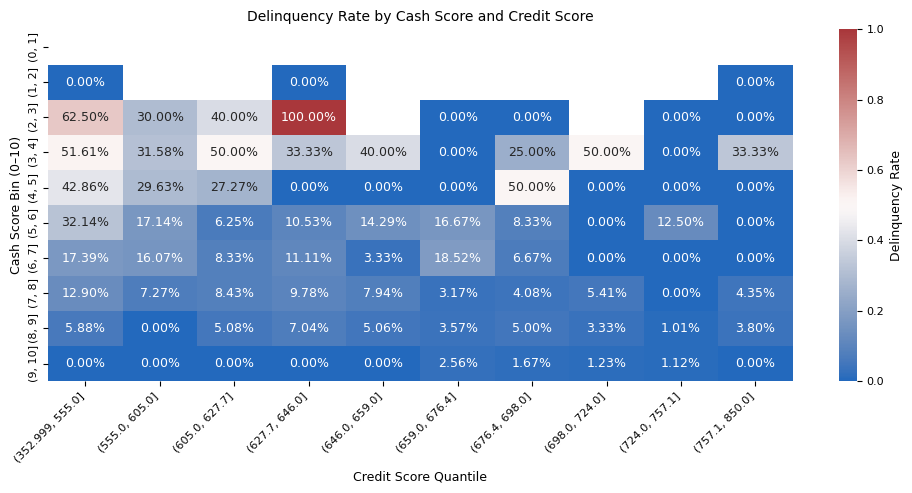

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = X_scored.copy()

# Ensure numeric 0/1
df["DQ_TARGET"] = pd.to_numeric(df["DQ_TARGET"], errors="coerce")

# Bin credit and cash
bins = np.arange(0, 11, 1)
bins[0] = -1e-8

df["cash_bin"] = pd.cut(
    df["cash_score"],
    bins=bins,
    right=True
)

df["credit_bin"] = pd.qcut(df["credit_score"], q=10)
# df["cash_bin"] = pd.cut(
#     df["cash_score"],
#     bins=np.arange(0, 11, 1),
#     include_lowest=True
# )

# Delinquency rate per cell: P(DQ=1 | cash_bin, credit_bin)
heat = (
    df
    .groupby(["cash_bin", "credit_bin"], observed=False)["DQ_TARGET"]
    .mean()
    .unstack()
)

# Make vmax a scalar (ignore NaNs)
vmax = np.nanmax(heat.to_numpy())

plt.figure(figsize=(10, 5))
sns.heatmap(
    heat,
    cmap="vlag",
    annot=True,
    fmt=".2%",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Delinquency Rate"}
)

plt.xlabel("Credit Score Quantile")
plt.ylabel("Cash Score Bin (0–10)")
plt.title("Delinquency Rate by Cash Score and Credit Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig("heatmap.png") 
plt.show()

# might need to standardize within column for coolors to be more apparent

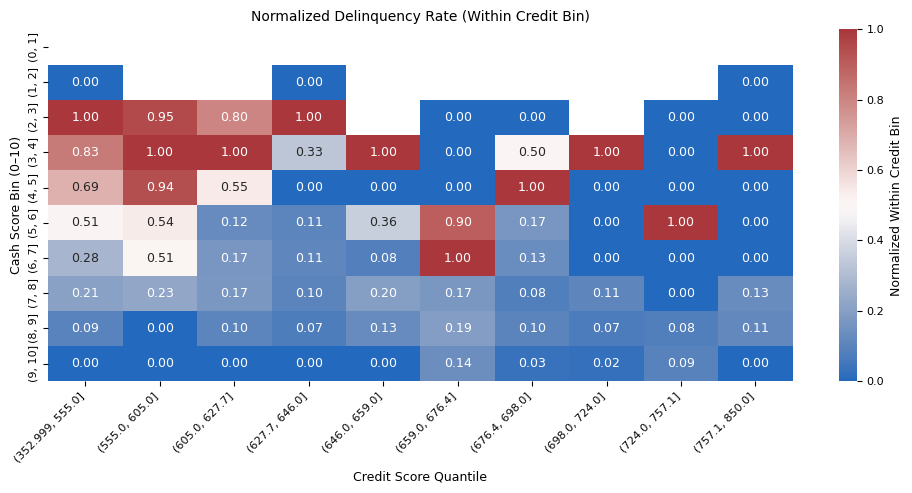

In [60]:
# Within a fixed credit score group, how strong is the relative cash score effect?
df = X_scored.copy()

# Ensure numeric 0/1
df["DQ_TARGET"] = pd.to_numeric(df["DQ_TARGET"], errors="coerce")

# Bin credit and cash
bins = np.arange(0, 11, 1)
bins[0] = -1e-8

df["cash_bin"] = pd.cut(
    df["cash_score"],
    bins=bins,
    right=True
)

df["credit_bin"] = pd.qcut(df["credit_score"], q=10)

heat = (
    df
    .groupby(["cash_bin", "credit_bin"], observed=False)["DQ_TARGET"]
    .mean()
    .unstack()
)

# ---- Normalize within each credit_bin (column-wise min-max) ----
heat_norm = heat.copy()

for col in heat_norm.columns:
    col_min = heat_norm[col].min()
    col_max = heat_norm[col].max()
    
    if col_max > col_min:
        heat_norm[col] = (heat_norm[col] - col_min) / (col_max - col_min)
    else:
        heat_norm[col] = 0  # if constant column

# Plot normalized heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    heat_norm,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Normalized Within Credit Bin"}
)

plt.xlabel("Credit Score Quantile")
plt.ylabel("Cash Score Bin (0–10)")
plt.title("Normalized Delinquency Rate (Within Credit Bin)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Relative deviation from credit-bin average
df = X_scored.copy()

# Ensure numeric 0/1
df["DQ_TARGET"] = pd.to_numeric(df["DQ_TARGET"], errors="coerce")

# Bin credit and cash
bins = np.arange(0, 11, 1)
bins[0] = -1e-8

df["cash_bin"] = pd.cut(
    df["cash_score"],
    bins=bins,
    right=True
)

df["credit_bin"] = pd.qcut(df["credit_score"], q=10)

heat = (
    df
    .groupby(["cash_bin", "credit_bin"], observed=False)["DQ_TARGET"]
    .mean()
    .unstack()
)

# ---- Normalize within each credit_bin (column-wise min-max) ----
heat_norm = heat.sub(heat.mean(axis=0), axis=1)

for col in heat_norm.columns:
    col_min = heat_norm[col].min()
    col_max = heat_norm[col].max()
    
    if col_max > col_min:
        heat_norm[col] = (heat_norm[col] - col_min) / (col_max - col_min)
    else:
        heat_norm[col] = 0  # if constant column

# Plot normalized heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    heat_norm,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Normalized Within Credit Bin"}
)

plt.xlabel("Credit Score Quantile")
plt.ylabel("Cash Score Bin (0–10)")
plt.title("Normalized Delinquency Rate (Within Credit Bin)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

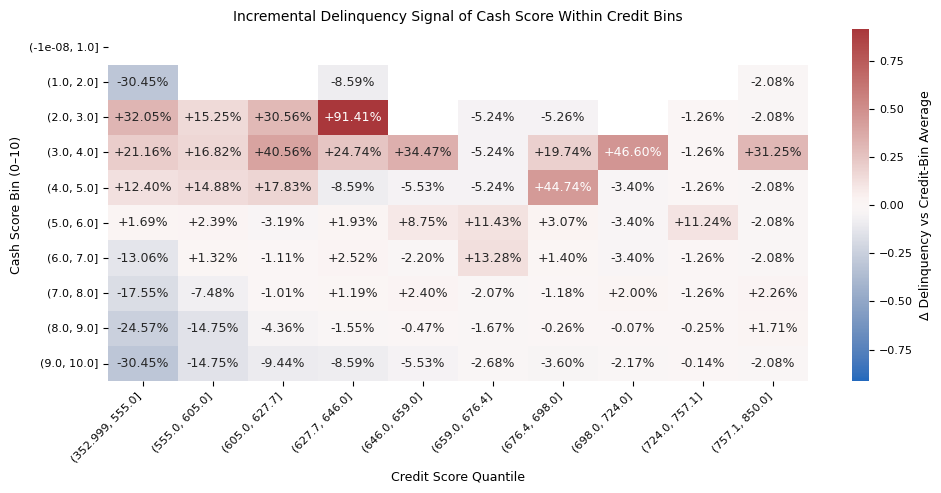

In [53]:
df = X_scored.copy()
df["DQ_TARGET"] = pd.to_numeric(df["DQ_TARGET"], errors="coerce")

# --- bins ---
bins = np.arange(0, 11, 1).astype(float)
bins[0] = -1e-8

df["cash_bin"] = pd.cut(df["cash_score"], bins=bins, right=True)
df["credit_bin"] = pd.qcut(df["credit_score"], q=10, duplicates="drop")

# --- cell delinquency: P(DQ=1 | cash_bin, credit_bin) ---
heat = (
    df.groupby(["cash_bin", "credit_bin"], observed=False)["DQ_TARGET"]
      .mean()
      .unstack()
)

# --- baseline delinquency per credit bin: P(DQ=1 | credit_bin) ---
credit_base = df.groupby("credit_bin", observed=False)["DQ_TARGET"].mean()

# --- incremental effect: subtract baseline within each credit bin (column-wise) ---
heat_delta = heat.sub(credit_base, axis=1)

# Symmetric color scale around 0
v = np.nanmax(np.abs(heat_delta.to_numpy()))

plt.figure(figsize=(10, 5))
sns.heatmap(
    heat_delta,
    cmap="vlag",
    annot=True,
    fmt="+.2%",
    vmin=-v,
    vmax=v,
    center=0,
    cbar_kws={"label": "Δ Delinquency vs Credit-Bin Average"}
)

plt.xlabel("Credit Score Quantile")
plt.ylabel("Cash Score Bin (0–10)")
plt.title("Incremental Delinquency Signal of Cash Score Within Credit Bins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Negative cells: cash_score bin is safer than average for that credit quantile.
# Positive cells: cash_score bin is riskier than average for that credit quantile.
# If you see a gradient down the rows within most columns, that’s strong evidence your Cash Score adds information beyond credit.

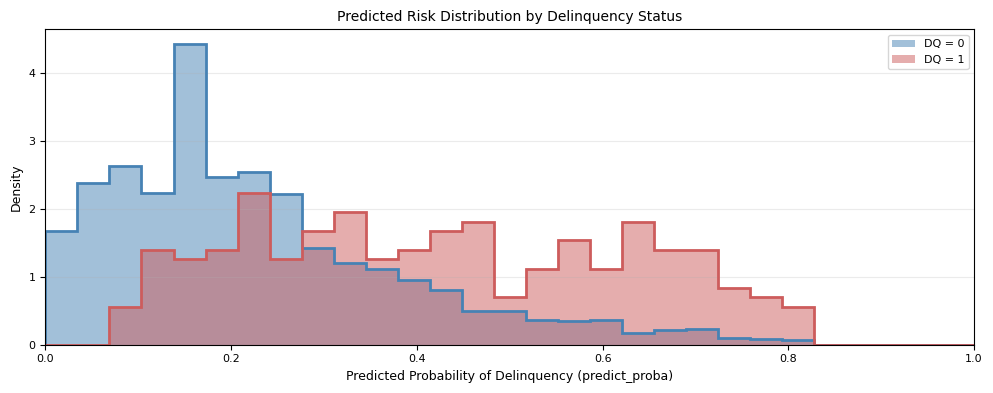

In [32]:
cash_0 = X_scored[X_scored["DQ_TARGET"] == 0]["predict_proba"]
cash_1 = X_scored[X_scored["DQ_TARGET"] == 1]["predict_proba"]

bins = np.linspace(0, 1, 30)  # 30 smooth bins between 0 and 1

plt.figure(figsize=(10, 4))

plt.hist(cash_0, bins=bins, alpha=0.5, density=True,
         color="steelblue", label="DQ = 0")
plt.hist(cash_0, bins=bins, density=True,
         histtype="step", linewidth=2,
         color="steelblue")

plt.hist(cash_1, bins=bins, alpha=0.5, density=True,
         color="indianred", label="DQ = 1")
plt.hist(cash_1, bins=bins, density=True,
         histtype="step", linewidth=2,
         color="indianred")

plt.xlabel("Predicted Probability of Delinquency (predict_proba)")
plt.ylabel("Density")
plt.title("Predicted Risk Distribution by Delinquency Status")

plt.xlim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

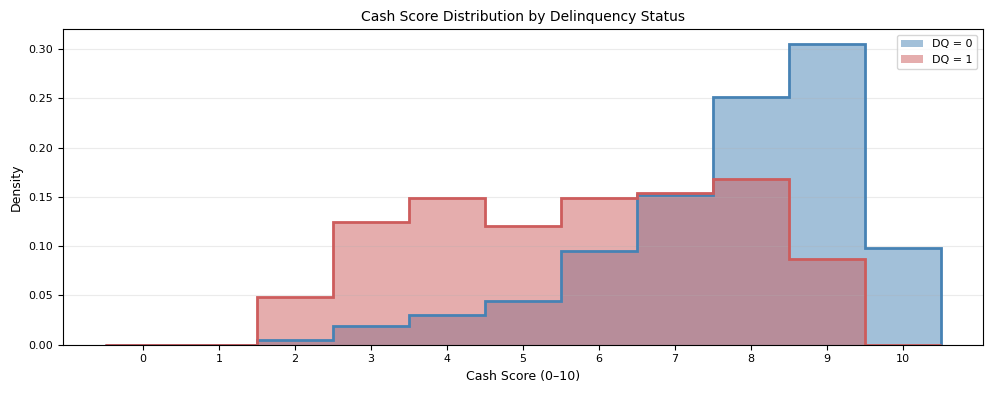

In [33]:
cash_0 = X_scored[X_scored["DQ_TARGET"] == 0]["cash_score"]
cash_1 = X_scored[X_scored["DQ_TARGET"] == 1]["cash_score"]

bins = np.arange(-0.5, 11.5, 1)

plt.figure(figsize=(10, 4))

# DQ = 0
plt.hist(cash_0, bins=bins, alpha=0.5, density=True,
         color="steelblue", label="DQ = 0")
plt.hist(cash_0, bins=bins, density=True,
         histtype="step", linewidth=2,
         color="steelblue")

# DQ = 1
plt.hist(cash_1, bins=bins, alpha=0.5, density=True,
         color="indianred", label="DQ = 1")
plt.hist(cash_1, bins=bins, density=True,
         histtype="step", linewidth=2,
         color="indianred")

plt.xlabel("Cash Score (0–10)")
plt.ylabel("Density")
plt.title("Cash Score Distribution by Delinquency Status")
plt.xticks(range(0, 11))
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [34]:
X_scored['credit_bin'].value_counts()

credit_bin
(627.7, 646.0]      256
(676.4, 698.0]      247
(555.0, 605.0]      244
(352.999, 555.0]    243
(757.1, 850.0]      240
(724.0, 757.1]      238
(646.0, 659.0]      235
(698.0, 724.0]      235
(605.0, 627.7]      233
(659.0, 676.4]      229
Name: count, dtype: int64

In [73]:
X_scored["credit_bin"].cat.categories[1]

Interval(555.0, 605.0, closed='right')

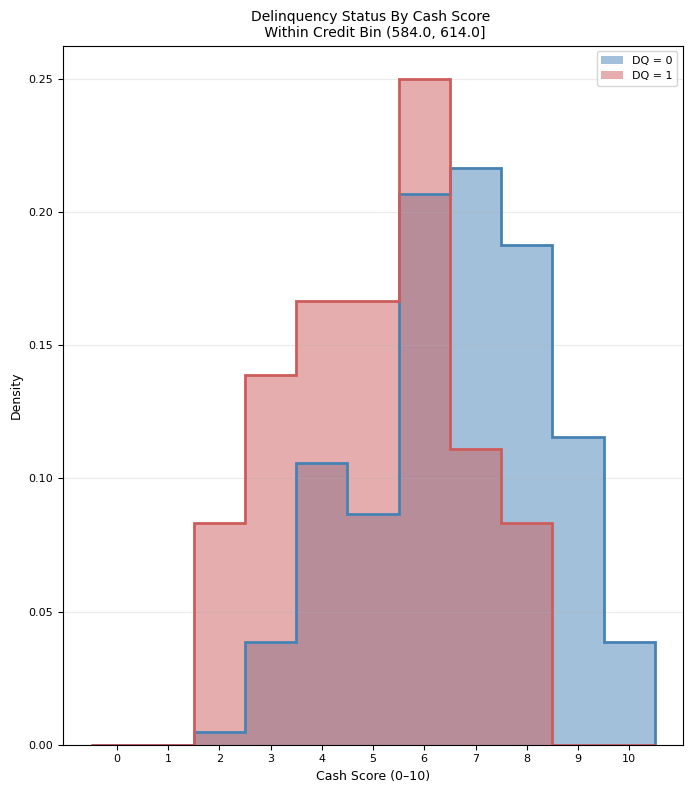

In [72]:
X_scored = X_scored.copy()

# recompute bins on the merged df
X_scored["credit_bin"] = pd.qcut(X_scored["credit_score"], q=10)

interval = X_scored["credit_bin"].cat.categories[1]  # pick the 4th bin for example
credit_filtered = X_scored[X_scored["credit_bin"] == interval]

cash_0 = credit_filtered[credit_filtered["DQ_TARGET"] == 0]["cash_score"]
cash_1 = credit_filtered[credit_filtered["DQ_TARGET"] == 1]["cash_score"]

bins = np.arange(-0.5, 11.5, 1)

plt.figure(figsize=(7, 8))

# DQ = 0
plt.hist(cash_0, bins=bins, alpha=0.5, density=True,
         color="steelblue", label="DQ = 0")
plt.hist(cash_0, bins=bins, density=True,
         histtype="step", linewidth=2,
         color="steelblue")

# DQ = 1
plt.hist(cash_1, bins=bins, alpha=0.5, density=True,
         color="indianred", label="DQ = 1")
plt.hist(cash_1, bins=bins, density=True,
         histtype="step", linewidth=2,
         color="indianred")

plt.xlabel("Cash Score (0–10)")
plt.ylabel("Density")
plt.title("Delinquency Status By Cash Score \n Within Credit Bin (584.0, 614.0]")
plt.xticks(range(0, 11))
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("DQ_within_lowest_credit_bin.png") 
plt.show()

In [36]:
credit_filtered

,prism_consumer_id,predict_proba,cash_score,credit_score,DQ_TARGET,cash_bin,credit_bin
0,1935,0.093480,9.07,612.0,0.0,"(9.02, 9.45]","(605.0, 627.7]"
5,11663,0.154289,8.46,614.0,0.0,"(8.414, 8.56]","(605.0, 627.7]"
14,6224,0.249221,7.51,616.0,0.0,"(7.08, 7.576]","(605.0, 627.7]"
19,1825,0.054510,9.45,610.0,0.0,"(9.02, 9.45]","(605.0, 627.7]"
25,11786,0.259063,7.41,618.0,0.0,"(7.08, 7.576]","(605.0, 627.7]"
...,...,...,...,...,...,...,...
2343,10187,0.284233,7.16,620.0,0.0,"(7.08, 7.576]","(605.0, 627.7]"
2356,10339,0.123288,8.77,622.0,0.0,"(8.56, 9.02]","(605.0, 627.7]"
2370,11693,0.207995,7.92,623.0,0.0,"(7.576, 7.975]","(605.0, 627.7]"
2375,12657,0.234591,7.65,622.0,0.0,"(7.576, 7.975]","(605.0, 627.7]"


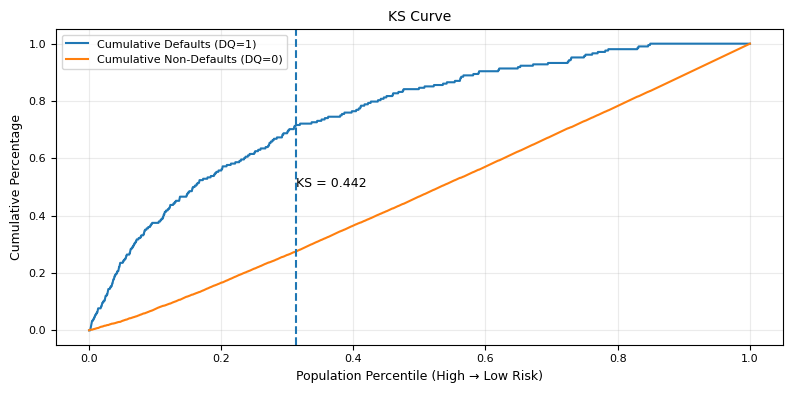

KS Statistic: 0.442


In [37]:
df = X_test_scored[["predict_proba", "DQ_TARGET"]].dropna().copy()

# Sort high risk → low risk
df = df.sort_values("predict_proba", ascending=False).reset_index(drop=True)

# Totals
n_defaults = (df["DQ_TARGET"] == 1).sum()
n_nondefaults = (df["DQ_TARGET"] == 0).sum()

# Cumulative %
df["cum_default_pct"] = (df["DQ_TARGET"] == 1).cumsum() / n_defaults
df["cum_nondefault_pct"] = (df["DQ_TARGET"] == 0).cumsum() / n_nondefaults
df["population_pct"] = np.arange(1, len(df)+1) / len(df)

# KS statistic
df["ks_diff"] = df["cum_default_pct"] - df["cum_nondefault_pct"]
ks_stat = df["ks_diff"].max()
ks_loc = df["population_pct"][df["ks_diff"].idxmax()]

# Plot
plt.figure(figsize=(8,4))

plt.plot(df["population_pct"], df["cum_default_pct"], label="Cumulative Defaults (DQ=1)")
plt.plot(df["population_pct"], df["cum_nondefault_pct"], label="Cumulative Non-Defaults (DQ=0)")

plt.axvline(ks_loc, linestyle="--")
plt.text(ks_loc, 0.5, f"KS = {ks_stat:.3f}")

plt.xlabel("Population Percentile (High → Low Risk)")
plt.ylabel("Cumulative Percentage")
plt.title("KS Curve")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("KS Statistic:", round(ks_stat, 3))